# 供应链延迟交付预测 — 分位数回归方法

**新思路：不预测「会不会延迟」，而是预测「会延迟几天」。**

传统做法是二分类，本项目换成**分位数回归**：
- 直接预测延迟天数的分布（P10/P50/P90）
- 根据预测分布和企业成本函数，计算每个订单的最优干预决策
- 阈值不是固定的，而是由成本结构动态决定

**数据：** DataCo Supply Chain（180K+ 订单）

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print('Ready')

Ready


## 1. 数据加载与目标变量构造

Orders: 180,519
Mean delay: 0.54 days
Median delay: 1.00 days
Late rate (delay>0): 54.7%


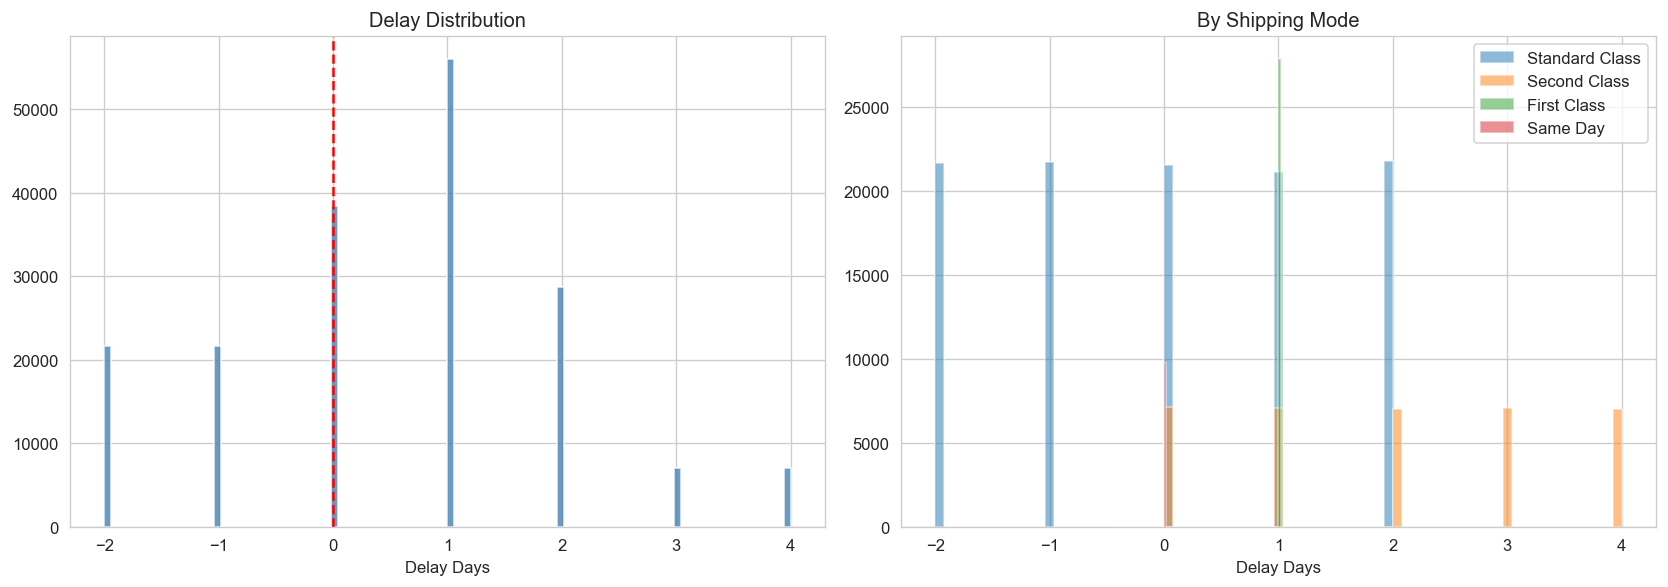

Saved


In [2]:
df = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])
df = df.sort_values('order date (DateOrders)').reset_index(drop=True)

df['actual_days'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['scheduled_days'] = df['Days for shipment (scheduled)']
df['delay_days'] = df['actual_days'] - df['scheduled_days']

print(f'Orders: {len(df):,}')
print(f'Mean delay: {df.delay_days.mean():.2f} days')
print(f'Median delay: {df.delay_days.median():.2f} days')
print(f'Late rate (delay>0): {(df.delay_days>0).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['delay_days'], bins=100, color='steelblue', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Delay Days'); axes[0].set_title('Delay Distribution')

for sm in df['Shipping Mode'].unique()[:4]:
    axes[1].hist(df[df['Shipping Mode']==sm]['delay_days'], bins=50, alpha=0.5, label=sm)
axes[1].set_xlabel('Delay Days'); axes[1].set_title('By Shipping Mode'); axes[1].legend()
plt.tight_layout()
plt.savefig('../images/eda_delay_v6.png', dpi=150)
plt.show()
print('Saved')

## 2. 数据清洗（仅保留下单时可获得的信息）

In [3]:
keep_cols = ['Type','Category Name','Department Name','Market',
             'Shipping Mode','Customer Segment',
             'Days for shipment (scheduled)',
             'Order Item Quantity','Order Item Discount Rate']

df_model = df[keep_cols].copy()
od = df['order date (DateOrders)']

df_model['order_month'] = od.dt.month
df_model['order_dayofweek'] = od.dt.dayofweek
df_model['order_quarter'] = od.dt.quarter
df_model['order_is_weekend'] = (od.dt.dayofweek >= 5).astype(int)
df_model['order_dayofyear'] = od.dt.dayofyear
df_model['total_value'] = df['Order Item Quantity'] * df['Order Item Product Price']
df_model['discount_abs'] = df['Order Item Total'] * df['Order Item Discount Rate']
df_model['value_per_ship_day'] = df_model['total_value'] / (df_model['Days for shipment (scheduled)'] + 1)
df_model['is_high_discount'] = (df['Order Item Discount Rate'] > 0.1).astype(int)
df_model['is_bulk'] = (df['Order Item Quantity'] > 5).astype(int)
df_model['discount_x_value'] = df['Order Item Discount Rate'] * df_model['total_value']
df_model['qty_x_ship'] = df['Order Item Quantity'] * df['Days for shipment (scheduled)']

cat_cols = ['Type','Category Name','Department Name','Market','Shipping Mode','Customer Segment']
for col in cat_cols:
    df_model[f'{col}_enc'] = LabelEncoder().fit_transform(df_model[col].astype(str))

df_model = df_model.drop(columns=cat_cols + ['Days for shipment (scheduled)',
    'Order Item Quantity','Order Item Discount Rate']).fillna(0)

df_model['delay_days'] = df['delay_days'].values
y = df_model.pop('delay_days').values
X = df_model

print(f'Features: {X.shape[1]}, Target range: [{y.min():.0f}, {y.max():.0f}] days')
print(f'Samples: {len(X):,}')
for i, col in enumerate(X.columns):
    print(f'  {i+1:2d}. {col}')

Features: 18, Target range: [-2, 4] days
Samples: 180,519
   1. order_month
   2. order_dayofweek
   3. order_quarter
   4. order_is_weekend
   5. order_dayofyear
   6. total_value
   7. discount_abs
   8. value_per_ship_day
   9. is_high_discount
  10. is_bulk
  11. discount_x_value
  12. qty_x_ship
  13. Type_enc
  14. Category Name_enc
  15. Department Name_enc
  16. Market_enc
  17. Shipping Mode_enc
  18. Customer Segment_enc


## 3. 时间切分

In [4]:
n = len(X)
t_end = int(n*0.7); v_end = int(n*0.85)
X_tr = X.iloc[:t_end]; X_va = X.iloc[t_end:v_end]; X_te = X.iloc[v_end:]
y_tr = y[:t_end]; y_va = y[t_end:v_end]; y_te = y[v_end:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr); X_va_s = scaler.transform(X_va); X_te_s = scaler.transform(X_te)
print(f'Train:{len(X_tr):,} Val:{len(X_va):,} Test:{len(X_te):,}')
print(f'Mean delay: train={y_tr.mean():.2f} val={y_va.mean():.2f} test={y_te.mean():.2f}')

Train:126,363 Val:27,078 Test:27,078
Mean delay: train=0.54 val=0.53 test=0.54


## 4. 分位数回归模型（P10 / P50 / P90）

In [5]:
models_q = {}
for q in [0.1, 0.5, 0.9]:
    m = GradientBoostingRegressor(n_estimators=200, max_depth=8, learning_rate=0.05,
                                   loss='quantile', alpha=q, random_state=42)
    m.fit(X_tr_s, y_tr)
    models_q[q] = m
    pred = m.predict(X_va_s)
    cov = (y_va <= pred).mean()*100
    mae = mean_absolute_error(y_va, pred)
    print(f'  q={q}: MAE={mae:.2f}d, Coverage={cov:.1f}% (target {q*100:.0f}%)')

print('\nTest set calibration:')
p10 = models_q[0.1].predict(X_te_s)
p50 = models_q[0.5].predict(X_te_s)
p90 = models_q[0.9].predict(X_te_s)
for q, pred in [(0.1,p10),(0.5,p50),(0.9,p90)]:
    cov = (y_te <= pred).mean()*100
    print(f'  q={q}: coverage={cov:.1f}%')

  q=0.1: MAE=2.53d, Coverage=11.9% (target 10%)


  q=0.5: MAE=0.96d, Coverage=65.1% (target 50%)


  q=0.9: MAE=1.54d, Coverage=94.5% (target 90%)

Test set calibration:
  q=0.1: coverage=12.2%
  q=0.5: coverage=64.5%
  q=0.9: coverage=93.8%


## 5. 成本最优决策

In [6]:
INT_COST = 100
PENALTY = 200
TOL = 1

def prob_exceed(p10, p50, p90, th):
    if th <= p10: return 0.9
    if th >= p90: return 0.1
    if th <= p50: return 0.5 + 0.4*(p50-th)/(p50-p10)
    return 0.5 - 0.4*(th-p50)/(p90-p50)

prob = np.array([prob_exceed(a,b,c,TOL) for a,b,c in zip(p10,p50,p90)])
exp_delay = np.maximum(p50-TOL, 0)
exp_loss_no = prob * exp_delay * PENALTY
intervene = exp_loss_no > INT_COST

actual = y_te > TOL
caught = intervene & actual
missed = ~intervene & actual
fa = intervene & ~actual

print(f'Intervention rate: {intervene.mean()*100:.1f}%')
print(f'Recall: {caught.sum()/actual.sum()*100:.1f}%')
print(f'False alarm rate: {fa.sum()/intervene.sum()*100:.1f}%' if intervene.sum()>0 else '')

cost_all = len(y_te)*INT_COST
cost_none = actual.sum()*exp_delay.mean()*PENALTY
cost_mod = intervene.sum()*INT_COST + missed.sum()*exp_delay[missed].mean()*PENALTY
print(f'\nCost: Model=${cost_mod:,.0f} vs All=${cost_all:,.0f} vs None=${cost_none:,.0f}')
print(f'Save vs All: ${cost_all-cost_mod:,.0f}, vs None: ${cost_none-cost_mod:,.0f}')

Intervention rate: 17.7%
Recall: 44.5%
False alarm rate: 40.4%

Cost: Model=$509,322 vs All=$2,707,800 vs None=$242,636
Save vs All: $2,198,478, vs None: $-266,685


## 6. 对比二分类方法

In [7]:
y_tr_b = (y_tr>TOL).astype(int); y_va_b = (y_va>TOL).astype(int); y_te_b = (y_te>TOL).astype(int)
clf = XGBClassifier(n_estimators=200,max_depth=8,learning_rate=0.05,random_state=42,verbosity=0)
clf.fit(X_tr_s, y_tr_b)
y_prob = clf.predict_proba(X_te_s)[:,1]
y_pred_b = (y_prob>0.5).astype(int)

intv_b = y_pred_b==1
cost_bin = intv_b.sum()*INT_COST + ((~intv_b)&actual).sum()*exp_delay.mean()*PENALTY

print(f'Binary AUC: {roc_auc_score(y_te_b, y_prob):.4f}')
print(f'Binary F1: {f1_score(y_te_b, y_pred_b):.4f}')
print(f'Binary cost: ${cost_bin:,.0f}')
print(f'Quantile cost: ${cost_mod:,.0f}')
print(f'Quantile saves: ${cost_bin-cost_mod:,.0f} vs binary')

Binary AUC: 0.7649
Binary F1: 0.5180
Binary cost: $628,297
Quantile cost: $509,322
Quantile saves: $118,975 vs binary


## 7. 可视化

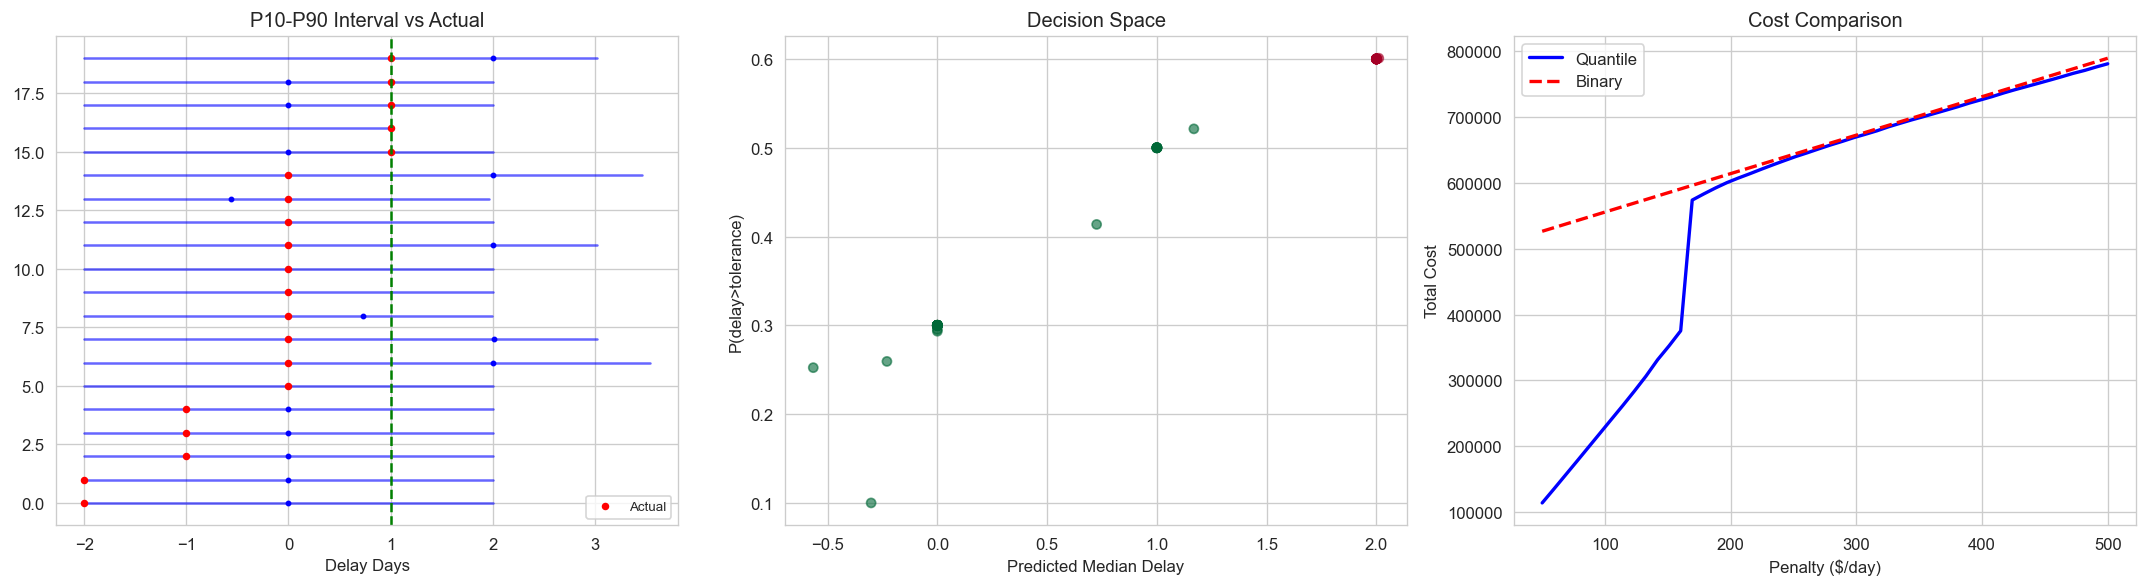

Done


In [8]:
np.random.seed(42); idx = np.random.choice(len(y_te), 50, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(18,5))
ax=axes[0]; si=np.argsort(y_te[idx])[:20]
for i,j in enumerate(si):
    ax.plot([p10[idx[j]],p90[idx[j]]],[i,i],'b-',linewidth=1.5,alpha=0.6)
    ax.plot(p50[idx[j]],i,'b.',markersize=5)
    ax.plot(y_te[idx[j]],i,'r.',markersize=7,label='Actual' if i==0 else '')
ax.set_xlabel('Delay Days'); ax.set_title('P10-P90 Interval vs Actual')
ax.axvline(TOL,color='green',linestyle='--'); ax.legend(fontsize=8)

ax=axes[1]
ax.scatter(p50[idx],prob[idx],c=intervene[idx].astype(int),cmap='RdYlGn_r',alpha=0.6,s=30)
ax.set_xlabel('Predicted Median Delay'); ax.set_ylabel('P(delay>tolerance)')
ax.set_title('Decision Space')

ax=axes[2]
ps=np.linspace(50,500,50); cq=[]; cb=[]
for p in ps:
    el=prob*np.maximum(p50-TOL,0)*p; iv=el>INT_COST
    cq.append(iv.sum()*INT_COST+((~iv)&actual).sum()*np.maximum(y_te[~iv]-TOL,0).mean()*p)
    cb.append(intv_b.sum()*INT_COST+((~intv_b)&actual).sum()*np.maximum(y_te[~intv_b]-TOL,0).mean()*p)
ax.plot(ps,cq,'b-',linewidth=2,label='Quantile'); ax.plot(ps,cb,'r--',linewidth=2,label='Binary')
ax.set_xlabel('Penalty ($/day)'); ax.set_ylabel('Total Cost'); ax.set_title('Cost Comparison'); ax.legend()
plt.tight_layout(); plt.savefig('../images/quantile_v6.png',dpi=150,bbox_inches='tight'); plt.show()
print('Done')

## 8. 总结

### 分位数回归 vs 二分类

| | 二分类 | 分位数回归 |
|------|------|------|
| 预测什么 | 延迟/不延迟 | 延迟几天 (P10/P50/P90) |
| 决策依据 | 固定阈值 0.5 | 成本函数动态决定 |
| 不确定性 | 无 | P10-P90 区间量化 |
| 灵活性 | 低 | 可调容忍天数、惩罚系数 |

### 核心价值

不是换了个模型——是换了一种思考方式。与其问「会不会延迟」，不如问「延迟多久、代价多大、值不值得干预」。这个视角的转变，比分位数回归的技术本身更重要。